In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input,Dense,Embedding,Flatten,Concatenate,Dropout,BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import shap
import tensorflow as tf

In [2]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

In [3]:
df = pd.read_csv('/Users/alfiyaansari/Desktop/IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv')
df.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...
2,2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...
3,3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...
4,4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...


In [4]:
categorical_features = [
    "Countries",
    "Local",
    "Industry Sector",
    "Genre",
    "Employee or Third Party",
    "Critical Risk",
    "Potential Accident Level"
]


In [5]:
for col in categorical_features:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [6]:
severity_map = {
    "i": 1,
    "ii": 2,
    "iii": 3,
    "iv": 4,
    "v": 5
}

df["risk_score"] = (
    df["Accident Level"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(severity_map)
)

df = df.dropna(subset=["risk_score"])

In [7]:
df["severe_accident"] = (df["risk_score"] >= 4).astype(int)

In [8]:
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [9]:
X = df[categorical_features]

y_risk = df["risk_score"]
y_severe = df["severe_accident"]

X_train, X_test, y_risk_train, y_risk_test, y_severe_train, y_severe_test = train_test_split(
    X, y_risk, y_severe,
    test_size=0.2,
    random_state=42
)

In [10]:
def build_model():
    inputs = []
    embeddings = []

    for col in categorical_features:
        inp = Input(shape=(1,), name=f"{col}_input")
        vocab_size = df[col].nunique() + 1

        emb = Embedding(vocab_size, 16)(inp)
        emb = Flatten()(emb)

        inputs.append(inp)
        embeddings.append(emb)

    x = Concatenate()(embeddings)

    x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)

    risk_output = Dense(1, activation="linear", name="risk_score")(x)
    severe_output = Dense(1, activation="sigmoid", name="severe_probability")(x)

    model = Model(inputs=inputs, outputs=[risk_output, severe_output])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss={
            "risk_score": tf.keras.losses.Huber(),
            "severe_probability": "binary_crossentropy"
        },
        metrics={
            "risk_score": "mae",
            "severe_probability": "accuracy"
        }
    )

    return model

In [11]:
model = build_model()

model.fit(
    [X_train[col] for col in categorical_features],
    {
        "risk_score": y_risk_train,
        "severe_probability": y_severe_train
    },
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.7045 - risk_score_loss: 0.8344 - risk_score_mae: 1.2536 - severe_probability_accuracy: 0.3510 - severe_probability_loss: 0.7517 - val_loss: 1.6912 - val_risk_score_loss: 1.0417 - val_risk_score_mae: 1.4006 - val_severe_probability_accuracy: 0.9118 - val_severe_probability_loss: 0.6692
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1991 - risk_score_loss: 0.4887 - risk_score_mae: 0.8256 - severe_probability_accuracy: 0.7290 - severe_probability_loss: 0.5937 - val_loss: 1.5743 - val_risk_score_loss: 0.9564 - val_risk_score_mae: 1.3063 - val_severe_probability_accuracy: 0.9118 - val_severe_probability_loss: 0.6338
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9206 - risk_score_loss: 0.3667 - risk_score_mae: 0.6971 - severe_probability_accuracy: 0.9230 - severe_probability_loss: 0.4342 - val_loss: 1.5147 - val_risk_score_loss: 0.9414 - val_risk_score_mae: 1.2887 - val_severe_probability_accuracy: 0.9118 - val

In [12]:
def encode_input(input_dict):
    encoded = []

    for col in categorical_features:
        value = input_dict[col].strip().lower()

        if value not in encoders[col].classes_:
            raise ValueError(
                f"Unseen label '{value}' for '{col}'. "
                f"Valid examples: {encoders[col].classes_[:5]}"
            )

        encoded.append(
            np.array([encoders[col].transform([value])[0]])
        )

    return encoded

In [13]:
def predict_all(model, input_dict):
    encoded = encode_input(input_dict)
    risk, severe = model.predict(encoded, verbose=0)

    return {
        "risk_score": round(float(risk[0][0]), 2),
        "severe_probability": round(float(severe[0][0]), 2)
    }

In [14]:
def what_if_analysis(model, base_input, modified_input):
    base_pred = predict_all(model, base_input)
    mod_pred = predict_all(model, modified_input)

    return {
        "baseline": base_pred,
        "modified": mod_pred,
        "risk_change": round(
            mod_pred["risk_score"] - base_pred["risk_score"], 2
        )
    }

In [15]:
base_input = {
    "Countries": encoders["Countries"].classes_[0],
    "Local": encoders["Local"].classes_[0],
    "Industry Sector": encoders["Industry Sector"].classes_[0],
    "Genre": encoders["Genre"].classes_[0],
    "Employee or Third Party": encoders["Employee or Third Party"].classes_[0],
    "Critical Risk": encoders["Critical Risk"].classes_[0],
    "Potential Accident Level": encoders["Potential Accident Level"].classes_[0]
}

modified_input = base_input.copy()
modified_input["Potential Accident Level"] = encoders[
    "Potential Accident Level"
].classes_[-1]

result = what_if_analysis(model, base_input, modified_input)
print(result)

{'baseline': {'risk_score': 0.79, 'severe_probability': 0.02}, 'modified': {'risk_score': 1.31, 'severe_probability': 0.46}, 'risk_change': 0.52}


In [ ]:
model.save("multi_output_accident_model")

In [4]:
df.shape

(425, 11)

In [5]:
severity_map = {
    'I' : 1, 'II' : 2, 'III' : 3, 'IV':4, 'V':5
}
df['risk_score'] = df['Accident Level'].map(severity_map)
df = df.dropna(subset=['risk_score'])

In [6]:
df.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,risk_score
0,0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,1
1,1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,1
2,2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,1
3,3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,1
4,4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,4


In [7]:
df['severe_accident'] = (df['risk_score'] >=4).astype(int)

In [8]:
categorical_features = [
    "Countries",'Local','Industry Sector','Genre','Employee or Third Party', 'Critical Risk','Potential Accident Level'
]

In [9]:
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [10]:
X = df[categorical_features]

y_risk = df["risk_score"]
y_severe = df["severe_accident"]

X_train, X_test, y_risk_train, y_risk_test, y_severe_train, y_severe_test = train_test_split(
    X, y_risk, y_severe,
    test_size=0.2,
    random_state=42
)


In [11]:
def build_model():
    inputs = []
    embeddings = []

    for col in categorical_features:
        inp = Input(shape=(1,), name=f"{col}_input")
        vocab_size = df[col].nunique() + 1

        emb = Embedding(vocab_size, 16)(inp)
        emb = Flatten()(emb)

        inputs.append(inp)
        embeddings.append(emb)

    x = Concatenate()(embeddings)

    x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)

    # 🎯 Output 1: Risk score (regression)
    risk_output = Dense(
        1, activation="linear", name="risk_score"
    )(x)

    # 🎯 Output 2: Severe accident probability
    severe_output = Dense(
        1, activation="sigmoid", name="severe_probability"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=[risk_output, severe_output]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss={
            "risk_score": tf.keras.losses.Huber(),
            "severe_probability": "binary_crossentropy"
        },
        metrics={
            "risk_score": "mae",
            "severe_probability": "accuracy"
        }
    )

    return model


In [12]:
model = build_model()

model.fit(
    [X_train[col] for col in categorical_features],
    {
        "risk_score": y_risk_train,
        "severe_probability": y_severe_train
    },
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.1263 - risk_score_loss: 0.5098 - risk_score_mae: 0.8327 - severe_probability_accuracy: 0.8378 - severe_probability_loss: 0.4980 - val_loss: 1.6426 - val_risk_score_loss: 1.0164 - val_risk_score_mae: 1.3762 - val_severe_probability_accuracy: 0.9118 - val_severe_probability_loss: 0.6411
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8715 - risk_score_loss: 0.4200 - risk_score_mae: 0.7699 - severe_probability_accuracy: 0.9128 - severe_probability_loss: 0.3309 - val_loss: 1.5845 - val_risk_score_loss: 0.9971 - val_risk_score_mae: 1.3561 - val_severe_probability_accuracy: 0.9118 - val_severe_probability_loss: 0.6001
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7532 - risk_score_loss: 0.3440 - risk_score_mae: 0.6601 - severe_probability_accuracy: 0.9096 - severe_probability_loss: 0.2910 - val_loss: 1.5564 - val_risk_score_loss: 1.0039 - val_risk_score_mae: 1.3627 - val_severe_probability_accuracy: 0.9118 - val

In [13]:
model.evaluate(
    [X_test[col] for col in categorical_features],
    {
        "risk_score": y_risk_test,
        "severe_probability": y_severe_test
    },
    verbose=1
)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6140 - risk_score_loss: 0.3648 - risk_score_mae: 0.6764 - severe_probability_accuracy: 0.9511 - severe_probability_loss: 0.1537 


[0.6395942568778992,
 0.37321701645851135,
 0.15831059217453003,
 0.6974619030952454,
 0.9411764740943909]

In [14]:
def encode_input(input_dict):
    return [
        np.array([encoders[col].transform([input_dict[col]])[0]])
        for col in categorical_features
    ]


In [15]:
def predict_all(model, input_dict):
    encoded = encode_input(input_dict)
    risk, severe = model.predict(encoded, verbose=0)

    return {
        "risk_score": round(float(risk[0][0]), 2),
        "severe_probability": round(float(severe[0][0]), 2)
    }


In [16]:
def what_if_analysis(model, base_input, modified_input):
    base_pred = predict_all(model, base_input)
    mod_pred = predict_all(model, modified_input)

    return {
        "baseline": base_pred,
        "modified": mod_pred,
        "risk_change": round(
            mod_pred["risk_score"] - base_pred["risk_score"], 2
        )
    }


In [17]:
base_input = {
    "Countries": "Brazil",
    "Local": "Plant A",
    "Industry Sector": "Mining",
    "Genre": "Male",
    "Employee or Third Party": "Employee",
    "Critical Risk": "Fall",
    "Potential Accident Level": "IV"
}

modified_input = base_input.copy()
modified_input["Potential Accident Level"] = "II"

result = what_if_analysis(model, base_input, modified_input)
print(result)


ValueError: y contains previously unseen labels: 'Brazil'

In [14]:
X = df[categorical_features]

y_risk = df["risk_score"]
y_severe = df["severe_accident"]

X_train, X_test, y_risk_train, y_risk_test, y_severe_train, y_severe_test = train_test_split(
    X, y_risk, y_severe,
    test_size=0.2,
    random_state=42
)

In [16]:
def build_model():
    inputs = []
    embeddings = []

    for col in categorical_features:
        inp = Input(shape=(1,), name=f"{col}_input")
        vocab_size = df[col].nunique() + 1

        emb = Embedding(vocab_size, 16)(inp)
        emb = Flatten()(emb)

        inputs.append(inp)
        embeddings.append(emb)

    x = Concatenate()(embeddings)

    x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)

    # Output 1: risk score
    risk_out = Dense(1, activation="linear", name="risk_score")(x)

    # Output 2: severe accident probability
    severe_out = Dense(1, activation="sigmoid", name="severe_probability")(x)

    model = Model(inputs=inputs, outputs=[risk_out, severe_out])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss={
            "risk_score": tf.keras.losses.Huber(),
            "severe_probability": "binary_crossentropy"
        },
        metrics={
            "risk_score": "mae",
            "severe_probability": "accuracy"
        }
    )

    return model



In [17]:
model = build_model()

model.fit(
    [X_train[col] for col in categorical_features],
    {
        "risk_score": y_risk_train,
        "severe_probability": y_severe_train
    },
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.2584 - risk_score_loss: 1.4311 - risk_score_mae: 1.9238 - severe_probability_accuracy: 0.5635 - severe_probability_loss: 0.7030 - val_loss: 1.7249 - val_risk_score_loss: 1.0758 - val_risk_score_mae: 1.4292 - val_severe_probability_accuracy: 0.9118 - val_severe_probability_loss: 0.6735
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4513 - risk_score_loss: 0.7773 - risk_score_mae: 1.1998 - severe_probability_accuracy: 0.8090 - severe_probability_loss: 0.5577 - val_loss: 1.6125 - val_risk_score_loss: 0.9847 - val_risk_score_mae: 1.3294 - val_severe_probability_accuracy: 0.9118 - val_severe_probability_loss: 0.6518
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1130 - risk_score_loss: 0.5242 - risk_score_mae: 0.8627 - severe_probability_accuracy: 0.8721 - severe_probability_loss: 0.4667 - val_loss: 1.4992 - val_risk_score_loss: 0.9009 - val_risk_score_mae: 1.2333 - val_severe_probability_accuracy: 0.9118 - val

In [18]:
model.evaluate(
    [X_test[col] for col in categorical_features],
    {
        "risk_score": y_risk_test,
        "severe_probability": y_severe_test
    },
    verbose=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5525 - risk_score_loss: 0.3016 - risk_score_mae: 0.5451 - severe_probability_accuracy: 0.9335 - severe_probability_loss: 0.1555


[0.5699502229690552,
 0.3052509129047394,
 0.15702305734157562,
 0.5580785274505615,
 0.929411768913269]

In [19]:
def model_predict(X):
    """
    X shape: (n_samples, n_features)
    Returns risk_score predictions only
    """
    inputs = [
        X[:, i].astype(int)
        for i in range(X.shape[1])
    ]
    preds = model(inputs, training=False)[0]
    return preds.numpy()


In [20]:
X_background = X_train.sample(50, random_state=42).values
X_explain = X_test.sample(50, random_state=42).values

In [21]:
explainer = shap.KernelExplainer(
    model_predict,
    X_background
)

shap_values = explainer.shap_values(
    X_explain,
    nsamples=100
)

  0%|          | 0/50 [00:00<?, ?it/s]

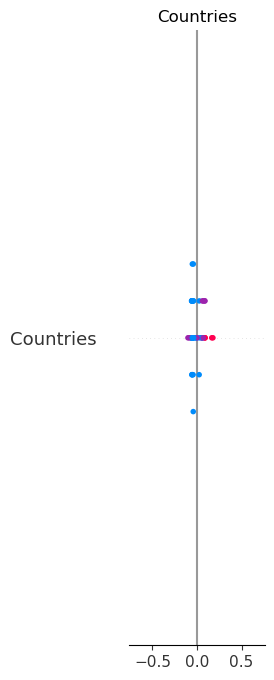

In [22]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=categorical_features
)

In [23]:
def encode_input(input_dict):
    return [
        np.array([encoders[col].transform([input_dict[col]])[0]])
        for col in categorical_features
    ]

In [24]:
def predict_all(model, input_dict):
    encoded = encode_input(input_dict)
    risk, severe = model.predict(encoded, verbose=0)

    return {
        "risk_score": round(float(risk[0][0]), 2),
        "severe_probability": round(float(severe[0][0]), 2)
    }

In [25]:
def what_if_analysis(model, base_input, modified_input):
    base_pred = predict_all(model, base_input)
    mod_pred = predict_all(model, modified_input)

    return {
        "baseline": base_pred,
        "modified": mod_pred,
        "risk_change": round(
            mod_pred["risk_score"] - base_pred["risk_score"], 2
        )
    }

In [26]:
base_input = {
    "Countries": "Brazil",
    "Local": "Plant A",
    "Industry Sector": "Mining",
    "Genre": "Male",
    "Employee or Third Party": "Employee",
    "Critical Risk": "Fall",
    "Potential Accident Level": "IV"
}

modified_input = base_input.copy()
modified_input["Potential Accident Level"] = "II"

result = what_if_analysis(model, base_input, modified_input)
print(result)

ValueError: y contains previously unseen labels: 'Brazil'